<a href="https://colab.research.google.com/github/vijenifer123-svg/yeuthuong-/blob/main/%C3%B4n_t%E1%BA%ADp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
dataframe= pd.read_csv('/content/Book15.csv')
dataframe

,STT,ho va ten,que quan,diem
0,1,kien,hcm,5
1,2,ql,hcm,10
2,3,vix,hanoi,8
3,4,r,hanoi,9
4,5,b,binhdinh,10
5,6,c,binhdinh,7
6,7,d,hungyen,10
7,8,e,hcm,10
8,9,f,hcm,10
9,10,kk,hcm,5


In [ ]:
a=pd.DataFrame()
a['name']=['quoc','hao']
a['diem']=[8,9]
a['que quan']=['hcm','hcm']
a

,name,diem,que quan
0,quoc,8,hcm
1,hao,9,hcm


In [ ]:
a.loc[2]=['khoi',10,'hcm']
a

,name,diem,que quan
0,quoc,8,hcm
1,hao,9,hcm
2,khoi,10,hcm


In [ ]:
dataframe.head(4)


,STT,ho va ten,que quan,diem
0,1,kien,hcm,5
1,2,ql,hcm,10
2,3,vix,hanoi,8
3,4,r,hanoi,9


In [ ]:
dataframe.describe()

,STT,diem
count,19.000000,19.000000
mean,10.000000,8.736842
std,5.627314,1.820931
min,1.000000,5.000000
25%,5.500000,7.500000
50%,10.000000,10.000000
75%,14.500000,10.000000
max,19.000000,10.000000


In [ ]:
dataframe.isnull().sum()

,0
STT,0
ho va ten,0
que quan,0
diem,0


In [ ]:
dataframe.nunique()

,0
STT,19
ho va ten,19
que quan,6
diem,6


In [ ]:
dataframe.iloc[0:5]

,STT,ho va ten,que quan,diem
0,1,kien,hcm,5
1,2,ql,hcm,10
2,3,vix,hanoi,8
3,4,r,hanoi,9
4,5,b,binhdinh,10


In [ ]:
dataframe=dataframe.set_index(dataframe['ho va ten'])
dataframe.loc['kien']

,kien
STT,1
ho va ten,kien
que quan,hcm
diem,5


In [ ]:
dataframe.iloc[0]

,kien
STT,1
ho va ten,kien
que quan,hcm
diem,5


In [ ]:
dataframe[dataframe['diem']==10].head(5)

,STT,ho va ten,que quan,diem
ho va ten,,,,
ql,2,ql,hcm,10
b,5,b,binhdinh,10
d,7,d,hungyen,10
e,8,e,hcm,10
f,9,f,hcm,10


In [ ]:
from geopy.geocoders import Nominatim
a=Nominatim(user_agent='geo')
location=a.geocode('Ben Thanh Market, Ho Chi Minh City')
print(f"ten:{location.address}")
print(f"toa do:{location.latitude},{location.longitude}")

ten:Chợ Bến Thành, Công trường Quách Thị Trang, Khu phố 6, Phường Bến Thành, Thủ Đức, Thành phố Hồ Chí Minh, 71009, Việt Nam
toa do:10.7725301,106.6980365


In [ ]:
location=a.reverse('10.7758, 106.7009')
print(f"ten:{location.address}")

ten:Nhà Hàng Cung Đình Rex, 146, Pasteur, Khu phố 6, Phường Sài Gòn, Thủ Đức, Thành phố Hồ Chí Minh, 71006, Việt Nam


In [ ]:

from geopy.distance import distance
point_a=('10.7758, 106.7009')
point_b=('(10.762622, 106.660172')
distance=distance(point_a,point_b).km
print(f"khoangcach:{distance:.2f}")

khoangcach:4.69


In [ ]:
from geopy.distance import distance
warehouse=('10.7769, 106.7009')
customer= [("Khách hàng 1", ('10.762, 106.682')),
    ("Khách hàng 2", ('10.751, 106.674')),
    ("Khách hàng 3", ('10.768, 106.708'))]
for name,coord in customer:
 dist=distance(warehouse,coord).km
 print(f"{name}:{dist:.2f}km tu khoa")

Khách hàng 1:2.64km tu khoa
Khách hàng 2:4.11km tu khoa
Khách hàng 3:1.25km tu khoa


In [ ]:
from geopy.distance import distance
user = (10.770, 106.690)
stations = [
    ("Trạm 1", (10.779, 106.700)),
    ("Trạm 2", (10.755, 106.685)),
    ("Trạm 3", (10.782, 106.675))]
danhsach=[]
for name,coord in stations:
  dist=distance(user,coord).km
  list.append(dist,name)
nearest=min(danhsach)
print(f"gan nhat:{nearest}({dist:.2f})")


TypeError: list.append() takes exactly one argument (2 given)

In [ ]:
import folium
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import time

# 1. Khởi tạo Geocoder
# Khai báo user_agent để sử dụng API của Nominatim
geolocator = Nominatim(user_agent="logistics_routing_app")

# Xác định điểm trung tâm (Ví dụ: UEH Cơ sở B)
center_address = "279 Nguyễn Tri Phương, Phường 5, Quận 10, Ho Chi Minh City"
print("Đang lấy tọa độ điểm trung tâm...")
center_location = geolocator.geocode(center_address)
center_coords = (center_location.latitude, center_location.longitude)

# Danh sách 10 địa chỉ giả lập (các điểm giao hàng/điểm nút giao thông)
addresses = [
    "Chợ Bến Thành, Quận 1, Ho Chi Minh City",
    "Bệnh viện Chợ Rẫy, Quận 5, Ho Chi Minh City",
    "Landmark 81, Bình Thạnh, Ho Chi Minh City",
    "Sân bay Tân Sơn Nhất, Tân Bình, Ho Chi Minh City",
    "Bến xe Miền Đông, Bình Thạnh, Ho Chi Minh City",
    "Chợ Bình Tây, Quận 6, Ho Chi Minh City",
    "Sân vận động Thống Nhất, Quận 10, Ho Chi Minh City",
    "Bưu điện trung tâm Sài Gòn, Quận 1, Ho Chi Minh City",
    "Khu công nghệ cao, Quận 9, Ho Chi Minh City",
    "Chợ An Đông, Quận 5, Ho Chi Minh City"
]

# 2. Thu thập tọa độ và tính khoảng cách
locations_data = []
print("Đang xử lý tọa độ và tính toán khoảng cách cho 10 địa điểm...")

for addr in addresses:
    loc = geolocator.geocode(addr)
    if loc:
        coords = (loc.latitude, loc.longitude)
        # Tính khoảng cách đường chim bay (Geodesic distance) từ điểm trung tâm đến địa chỉ
        dist = geodesic(center_coords, coords).kilometers

        locations_data.append({
            'name': addr.split(',')[0], # Lấy tên ngắn gọn
            'coords': coords,
            'distance': dist
        })
    else:
        print(f"Không tìm thấy tọa độ cho: {addr}")

    # Nghỉ 1 giây sau mỗi request để tránh lỗi Timeout từ Nominatim
    time.sleep(1)

# 3. Trực quan hóa bằng Folium
# Khởi tạo bản đồ lấy điểm trung tâm làm gốc
m = folium.Map(location=center_coords, zoom_start=13)

# Đánh dấu (Marker) cho điểm trung tâm
folium.Marker(
    location=center_coords,
    popup="<b>TRUNG TÂM (UEH)</b>",
    icon=folium.Icon(color='red', icon='star', prefix='fa')
).add_to(m)

# Thêm 10 điểm còn lại và vẽ đường nối thể hiện mối quan hệ không gian
for data in locations_data:
    # Thêm Marker cho từng địa điểm
    folium.Marker(
        location=data['coords'],
        popup=f"<b>{data['name']}</b><br>Khoảng cách: {data['distance']:.2f} km",
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(m)

    # Vẽ đường thẳng (PolyLine) nối từ trung tâm đến điểm giao nhận
    folium.PolyLine(
        locations=[center_coords, data['coords']],
        color='gray',
        weight=2,
        dash_array='5, 5', # Nét đứt thể hiện khoảng cách không gian
        tooltip=f"{data['distance']:.2f} km" # Hiển thị khoảng cách khi di chuột vào đường nối
    ).add_to(m)

# 4. Xuất kết quả
file_name = 'ban_do_bai_23_2.html'
m.save(file_name)
print(f"\nHoàn tất! Đã lưu bản đồ vào file: {file_name}")
print("Bạn hãy mở file này bằng trình duyệt web (Chrome/Edge) để xem bản đồ tương tác.")

Đang lấy tọa độ điểm trung tâm...


GeocoderUnavailable: HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Max retries exceeded with url: /search?q=279+Nguy%E1%BB%85n+Tri+Ph%C6%B0%C6%A1ng%2C+Ph%C6%B0%E1%BB%9Dng+5%2C+Qu%E1%BA%ADn+10%2C+Ho+Chi+Minh+City&format=json&limit=1 (Caused by ReadTimeoutError("HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Read timed out. (read timeout=1)"))

In [ ]:
import pandas as pd
import time
from geopy.geocoders import Nominatim
dt=pd.DataFrame()
dt['Dia diem']: [
        'Bệnh viện Chợ Rẫy, 201B Nguyễn Chí Thanh, Phường 12, Chợ Lớn, Hồ Chí Minh 700000, Việt Nam',
        'Bệnh viện Đại học Y Dược,215 Đ. Hồng Bàng, Chợ Lớn, Hồ Chí Minh 700000, Việt Nam',
        'Bệnh viện Nguyễn Tri Phương, 468 Nguyễn Trãi, Phường 7, An Đông, Hồ Chí Minh 70000, Việt Nam',
        'Chợ An Đông,34-36 An Dương Vương, Phường 9, An Đông, Hồ Chí Minh 700000, Việt Nam',
        'Vạn Hạnh Mall,11 Sư Vạn Hạnh, Hòa Hưng, Hồ Chí Minh 700000, Việt Nam',
        'Miếu Bà Thiên Hậu,710 Nguyễn Trãi, Chợ Lớn, Hồ Chí Minh 70000, Việt Nam',
        'Chợ Hồ Thị Kỷ,Hẻm 52 Hồ Thị Kỷ, Phường 1, Vườn Lài, Hồ Chí Minh 700000, Việt Nam',
        'Co.opmart Lý Thường Kiệt,497 Hoà Hảo, Phường 7, Diên Hồng, Hồ Chí Minh, Việt Nam',
        'Chợ Bình Tây,57A Tháp Mười, Bình Tây, Hồ Chí Minh, Việt Nam',
        'Sân vận động Thống Nhất,138 Đ. Đào Duy Từ, Phường 6, Diên Hồng, Hồ Chí Minh, Việt Nam']
a=Nominatim(user_agent='leo')
for i,row in dt.iterrows():
  ten_dia_diem = row['Dia diem'] + ", Ho Chi Minh City"
  location = a.geocode(ten_dia_diem)
  if location:
        print(f"ten: {location.address}")
        print(f"toa do: {location.latitude},{location.longitude}")
  else:
        print(f"Không tìm thấy tọa độ cho: {ten_dia_diem}")
  time.sleep(3)

In [ ]:
from geopy.geocoders import Nominatim
from geopy.distance import distance  # Dùng hàm distance theo Slide 35
import folium
import time

# --- BƯỚC 1: LẤY TỌA ĐỘ (Theo Slide 32 - Geocoding) ---
geolocator = Nominatim(user_agent="geoapi")

# Lấy tọa độ kho hàng (Ví dụ: UEH)
location_center = geolocator.geocode("279 Nguyễn Tri Phương, Ho Chi Minh City")
warehouse = (location_center.latitude, location_center.longitude)

# Danh sách địa điểm (mình rút gọn chuỗi để API dễ tìm như nhận xét trước)
danh_sach_dia_diem = [
    "Bệnh viện Chợ Rẫy, Ho Chi Minh City",
    "Bệnh viện Đại học Y Dược, Ho Chi Minh City",
    "Bệnh viện Nguyễn Tri Phương, Ho Chi Minh City",
    "Chợ An Đông, Ho Chi Minh City",
    "Vạn Hạnh Mall, Ho Chi Minh City",
    "Miếu Bà Thiên Hậu, Ho Chi Minh City",
    "Chợ Hồ Thị Kỷ, Ho Chi Minh City",
    "Co.opmart Lý Thường Kiệt, Ho Chi Minh City",
    "Chợ Bình Tây, Ho Chi Minh City",
    "Sân vận động Thống Nhất, Ho Chi Minh City"
]

# Tạo list chứa (Tên, (lat, lon)) giống cấu trúc biến 'customers' ở Slide 35
customers = []
print("Đang lấy tọa độ các điểm...")
for dia_diem in danh_sach_dia_diem:
    loc = geolocator.geocode(dia_diem)
    if loc:
        ten_ngan = dia_diem.split(",")[0] # Lấy tên ngắn gọn
        coord = (loc.latitude, loc.longitude)
        customers.append((ten_ngan, coord))
    time.sleep(1) # Tránh bị lỗi API do gửi quá nhanh

# --- BƯỚC 2 & 3: TÍNH KHOẢNG CÁCH VÀ VẼ BẢN ĐỒ ---

# Khởi tạo bản đồ (Theo Slide 38)
m = folium.Map(location=[warehouse[0], warehouse[1]], zoom_start=13)

# Vẽ Marker cho kho hàng trung tâm (Theo Slide 38)
folium.Marker(
    [warehouse[0], warehouse[1]],
    popup="Trung tâm (UEH)",
    tooltip="Kho hàng"
).add_to(m)

print("\nKết quả khoảng cách:")
# Vòng lặp tính khoảng cách (Giống hệt cấu trúc Slide 35)
for name, coord in customers:

    # 1. Tính khoảng cách (Theo Slide 35)
    dist = distance(warehouse, coord).km
    print(f"{name}: {dist:.2f} km từ kho")

    # 2. Thêm Marker cho từng điểm (Theo Slide 38)
    popup_text = f"{name} - {dist:.2f} km"
    folium.Marker(
        [coord[0], coord[1]],
        popup=popup_text,
        tooltip="Click vào"
    ).add_to(m)

    # 3. Vẽ đường thẳng Polyline nối từ kho đến điểm giao (Theo Slide 39)
    folium.PolyLine(
        [[warehouse[0], warehouse[1]], [coord[0], coord[1]]],
        color="blue"
    ).add_to(m)

# Hiển thị bản đồ trong Colab
m

Đang lấy tọa độ các điểm...

Kết quả khoảng cách:
Bệnh viện Chợ Rẫy: 1.14 km từ kho
Bệnh viện Đại học Y Dược: 0.88 km từ kho
Bệnh viện Nguyễn Tri Phương: 0.84 km từ kho
Chợ An Đông: 0.83 km từ kho
Vạn Hạnh Mall: 0.86 km từ kho
Miếu Bà Thiên Hậu: 1.28 km từ kho
Chợ Hồ Thị Kỷ: 1.03 km từ kho
Chợ Bình Tây: 2.42 km từ kho
Sân vận động Thống Nhất: 0.58 km từ kho


In [ ]:
import pandas as pd
dt=pd.DataFrame()
dt['Dia diem']= [
         "Bệnh viện Chợ Rẫy, Ho Chi Minh City",
    "Bệnh viện Đại học Y Dược, Ho Chi Minh City",
    "Bệnh viện Nguyễn Tri Phương, Ho Chi Minh City",
    "Chợ An Đông, Ho Chi Minh City",
    "Vạn Hạnh Mall, Ho Chi Minh City",
    "Miếu Bà Thiên Hậu, Ho Chi Minh City",
    "Chợ Hồ Thị Kỷ, Ho Chi Minh City",
    "Co.opmart Lý Thường Kiệt, Ho Chi Minh City",
    "Chợ Bình Tây, Ho Chi Minh City",
    "Sân vận động Thống Nhất, Ho Chi Minh City"
]
dt

,Dia diem
0,"Bệnh viện Chợ Rẫy, Ho Chi Minh City"
1,"Bệnh viện Đại học Y Dược, Ho Chi Minh City"
2,"Bệnh viện Nguyễn Tri Phương, Ho Chi Minh City"
3,"Chợ An Đông, Ho Chi Minh City"
4,"Vạn Hạnh Mall, Ho Chi Minh City"
5,"Miếu Bà Thiên Hậu, Ho Chi Minh City"
6,"Chợ Hồ Thị Kỷ, Ho Chi Minh City"
7,"Co.opmart Lý Thường Kiệt, Ho Chi Minh City"
8,"Chợ Bình Tây, Ho Chi Minh City"
9,"Sân vận động Thống Nhất, Ho Chi Minh City"


In [ ]:
from geopy.geocoders import Nominatim
a=Nominatim(user_agent='leo')
location=a.geocode('1 Đ. số 10, KCN Sóng Thần, Dĩ An, Hồ Chí Minh, Việt Nam')
print(f"dia diem:{location.latitude},{location.longitude}")

dia diem:10.8927542,106.7506871


In [ ]:
import folium
from folium.plugins import HeatMap

# Thêm tiles='cartodbpositron' để tránh lỗi Access Blocked và làm bản đồ đẹp hơn
m = folium.Map(location=[10.8811139, 106.8060415], zoom_start=13 )

# Dữ liệu tọa độ các trường đại học khu vực Thủ Đức/Dĩ An
heat_data = [
    [10.8526372, 106.7705794], # HUTECH
    [10.8531334, 106.7687191], # PTIT
    [10.8589467, 106.7695902], # Nông Lâm
    [10.8723254, 106.7889778]  # ĐHQG TP.HCM (Ví dụ)
    # ... bạn thêm tiếp các tọa độ còn lại vào đây
]

HeatMap(heat_data).add_to(m)
m

In [ ]:
import folium

# ---------------------------------------------------------
# BƯỚC 1: Xác định tọa độ Trung tâm phân phối (Kho hàng)
# Giả sử kho hàng đặt tại khu vực trung tâm TP.HCM
# ---------------------------------------------------------
center_coord = [10.776, 106.700]

# Khởi tạo bản đồ lấy kho hàng làm trung tâm
m = folium.Map(location=center_coord, zoom_start=12)

# Đánh dấu vị trí Trung tâm phân phối
folium.Marker(
    center_coord,
    popup="Trung tâm Phân phối (Kho chính)",
    icon=folium.Icon(color="red", icon="home")
).add_to(m)

# ---------------------------------------------------------
# BƯỚC 2: Vẽ các vùng bán kính phục vụ (Service Areas)
# ---------------------------------------------------------

# Vùng 1: Bán kính 3 km (3000 mét) - Vùng tiếp cận nhanh
folium.Circle(
    location=center_coord,
    radius=3000,
    color="green",
    fill=True,
    fill_opacity=0.2,
    tooltip="Vùng phục vụ 3 km"
).add_to(m)

# Vùng 2: Bán kính 5 km (5000 mét) - Vùng phục vụ tiêu chuẩn
folium.Circle(
    location=center_coord,
    radius=5000,
    color="blue",
    fill=True,
    fill_opacity=0.1,
    tooltip="Vùng phục vụ 5 km"
).add_to(m)

# Vùng 3: Bán kính 10 km (10000 mét) - Vùng tiếp cận mở rộng
folium.Circle(
    location=center_coord,
    radius=10000,
    color="orange",
    fill=True,
    fill_opacity=0.05,
    tooltip="Vùng phục vụ 10 km"
).add_to(m)

# ---------------------------------------------------------
# BƯỚC 3: Hiển thị bản đồ
# ---------------------------------------------------------
m

In [ ]:
import folium
from geopy.geocoders import Nominatim
import osmnx as ox
import networkx as nx
# Locations
address_A = "Ben Thanh Market, Ho Chi Minh City, Vietnam"
address_B = "Tan Son Nhat Airport, Ho Chi Minh City, Vietnam"
# Get coordinates
geolocator = Nominatim(user_agent="routing-example", timeout=10) # Added timeout
location_A = geolocator.geocode(address_A)
location_B = geolocator.geocode(address_B)
# Check if locations were found before proceeding
latlng_A = (location_A.latitude, location_A.longitude)
latlng_B = (location_B.latitude, location_B.longitude)
Route (Actual path)
# Download road network (graph) from OpenStreetMap
# Note: we take the road network in the area between A and B, radius about 3km
midpoint = ((latlng_A[0] + latlng_B[0]) / 2, (latlng_A[1] + latlng_B[1]) / 2)
G = ox.graph_from_point(midpoint, dist=3000, network_type='drive')
# Find the closest node to A and B
orig_node = ox.distance.nearest_nodes(G, latlng_A[1], latlng_A[0])
dest_node = ox.distance.nearest_nodes(G, latlng_B[1], latlng_B[0])
# Find the shortest path by length
route = nx.shortest_path(G, orig_node, dest_node, weight='length')
# Route coordinates
route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]
Route (Actual path)
# Create a map
m = folium.Map(location=midpoint, zoom_start=14)
# Add markers A and B
folium.Marker(latlng_A, popup="Điểm A", icon=folium.Icon(color='red')).add_to(m)
folium.Marker(latlng_B, popup="Điểm B", icon=folium.Icon(color='blue')).add_to(m)
# Draw the route according to reality
folium.PolyLine(locations=route_coords, color='green', weight=5, opacity=0.8).add_to(m)
# Show map
display(m

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3035727743.py, line 15)

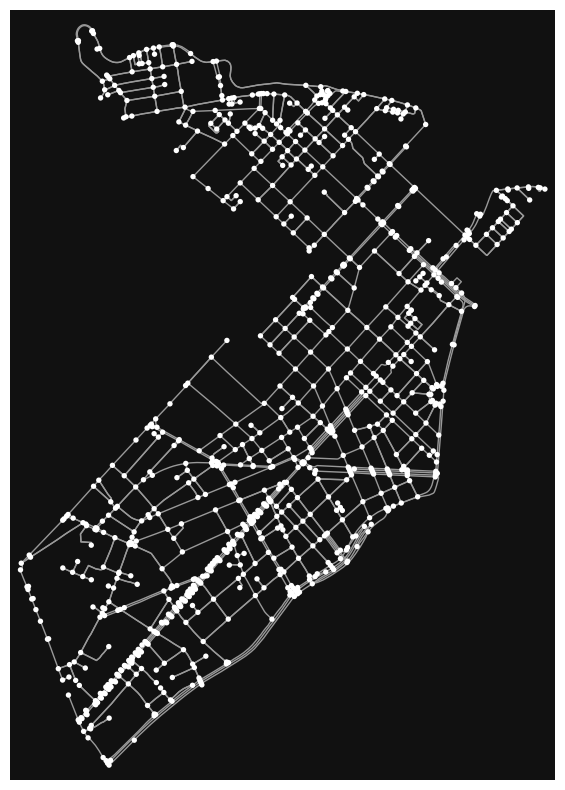

Số nút giao: 985
Số cạnh (đoạn đường): 2081
Chiều dài TB: 82 m


NameError: name 'folium' is not defined

In [ ]:
!pip install folium geopy osmnx networkx

import osmnx as ox
G = ox.graph_from_place("Quận 1, Hồ Chí Minh, Vietnam",
                         network_type='drive')
fig, ax = ox.plot_graph(G, figsize=(10, 10))
stats = ox.basic_stats(G)
print(f"Số nút giao: {stats['n']}")
print(f"Số cạnh (đoạn đường): {stats['m']}")
print(f"Chiều dài TB: {stats['street_length_avg']:.0f} m")
G_projected = ox.project_graph(G)
nodes, edges = ox.graph_to_gdfs(G)
m = folium.Map(location=[10.775, 106.700], zoom_start=14)
m.save("index1.html")
